# Armillary tutorial

Armillary builds a coordinate system for a set of stellar spectra from the spectra alone, and then carries labels (effective temperature, surface gravity, metallicity, or anything else measured for a few stars) to every other star through that coordinate system. This notebook walks through both steps on a small set of synthetic spectra shipped with the package, then shows how the same calls apply to a real survey.

The five steps of the method, and the module that implements each:

| step | what it does | module |
| --- | --- | --- |
| 1 | normalise each spectrum to a local continuum and measure a distance between every pair of spectra, from the cumulative absorption in a hierarchy of wavelength chunks | `preprocess`, `distance` |
| 2 | join every star to its nearest neighbours under that distance into one connected graph, and measure geodesic distances along it | `lattice` |
| 3 | turn the geodesic distances into coordinates (landmark multidimensional scaling) | `coordinates` |
| 4 | refine the coordinates so that every star is a local linear combination of its neighbours | `refine` |
| 5 | transfer labels from a few labelled stars to all the others through the same local combinations | `labels` |

`armillary.fit` runs steps 1 to 4 and returns a `Fit`; `Fit.propagate` is step 5.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import armillary as ar
from armillary import evaluate as ev
print("armillary", ar.__version__)

armillary 0.2.0


## 1. The example spectra

`examples/synthetic_spectra.npz` holds 2,100 synthetic spectra from 480 to 680 nm at a resolving power of 10,000: a survey-like "population" set (main-sequence stars, subgiants, red giants and red-clump stars) and a "random" set drawn uniformly over the label box. Each comes with its true effective temperature, surface gravity and metallicity. The spectra were calculated with [Payne Zero](https://github.com/tingyuansen/payne-zero) and are already continuum-normalised.

Synthetic stellar spectra for the Armillary tutorial: payne-zero (Ting 2026) one-dimensional LTE synthesis, 480 to 680 nm, degraded to a resolving power of 10,000 and sampled at 2.5 pixels per resolution element, continuum-normalised. 'population' (1,500): a survey-like mix of main-sequence stars, subgiants, red giants and red-clump stars; 'random' (600): uniform draws over Teff 4000-7000 K, log g 1-5, [Fe/H] -2 to +0.5. All have [alpha/M] = 0 and 1.5 km/s microturbulence. Arrays: flux [N, P] float16 (precision 5e-4; cast to float32 to use), wavelength_nm [P] float64, labels [N, 3] float32 (Teff, logg, [Fe/H]), sample [N] str.
(2100, 8702) spectra x pixels; 1500 population, 600 random


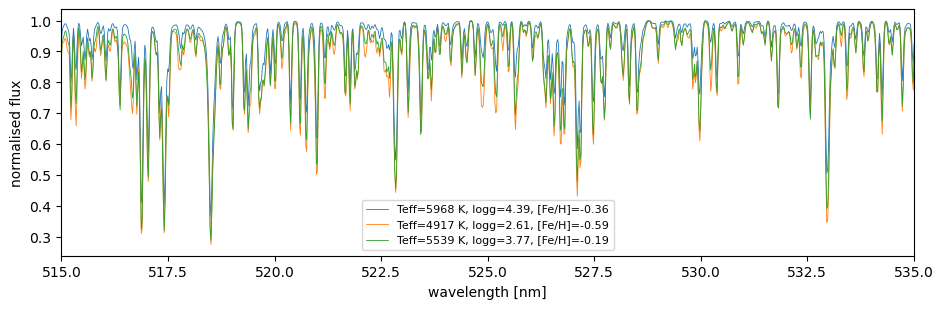

In [2]:
z = np.load("examples/synthetic_spectra.npz")
flux = z["flux"].astype(np.float32); wl = z["wavelength_nm"]; labels = z["labels"].astype(float); sample = z["sample"]
print(str(z["readme"]))
print(flux.shape, "spectra x pixels;", (sample == "population").sum(), "population,", (sample == "random").sum(), "random")

fig, ax = plt.subplots(figsize=(11, 3.2))
for i, c in zip([0, 700, 1400], ["C0", "C1", "C2"]):
    ax.plot(wl, flux[i], lw=0.6, color=c, label=f"Teff={labels[i,0]:.0f} K, logg={labels[i,1]:.2f}, [Fe/H]={labels[i,2]:.2f}")
ax.set_xlim(515, 535); ax.set_xlabel("wavelength [nm]"); ax.set_ylabel("normalised flux"); ax.legend(fontsize=8); plt.show()

## 2. The coordinates

`fit` needs three arrays: the flux, a boolean mask of the usable pixels, and the detector segment of every pixel (a single segment here). The configuration is a `Config`; `Config.paper_synthetic()` is the setting the Armillary paper used on its synthetic grid: one wavelength segment, one chunking of 32 chunks, three coordinates, and the refinement over each star's 50 nearest neighbours. The exact neighbour search is fine at this size (a few thousand stars); `search="nndescent"` is the setting for a survey of hundreds of thousands.

In [3]:
N, P = flux.shape
good = np.ones((N, P), bool)          # every pixel usable
segments = np.zeros(P, int)            # one detector segment
config = ar.Config.paper_synthetic()
F = ar.fit(flux, good, segments, config)

[     0s] fit: 2100 spectra x 8702 pixels; search exact; threads 10


[     2s] normalised flux: 8702 pixels, 1.8 s


[     2s] features: 8702 columns from [32] chunks, medians over 124750 pairs of 500 stars, 0.3 s


[     3s] neighbours: k = 50 by exact search, 1.2 s
[     3s] lattice: k-NN graph has 1 component(s)
[     3s] lattice: 39703 edges, 37.8 per star, 1 component(s), 0 bridge(s)


[     4s] geodesics: Dijkstra from 2100 landmark(s), 0.8 s


[     5s] coordinates: d = 3; eigenvalue ratios [1.0, 0.461, 0.097, 0.021, 0.014, 0.012, 0.011, 0.008], 1.2 s


[     6s] refinement weights on the 30-component projection (0.2 s), k = 50 neighbours under D (0.1 s)
[     6s] refined: rho = 0.003, max relative residual 9.9e-09, 0.1 s
[     6s] done in 6 s


The `Fit` keeps every intermediate product: the normalised flux `F.fn`, the feature vectors whose L1 distance is the spectral distance (`F.features`), each star's neighbours and distances (`F.nbr`, `F.dist`), the graph (`F.lattice`), the eigenvalues of the scaling, the unrefined and refined coordinates (`F.C_geo`, `F.C`), and the timings of every step.

The eigenvalues say how many coordinates the spectra need. With three labels varying, three coordinates carry the structure and the rest is small.

eigenvalue ratios: [1.    0.461 0.097 0.021 0.014 0.012 0.011 0.008]
seconds per step: {'normalise': 1.8, 'features': 0.3, 'neighbours': 1.2, 'lattice': 0.0, 'geodesics': 0.8, 'mds': 1.2, 'pca': 0.2, 'lle': 0.1, 'refine': 0.1, 'total': 5.8}


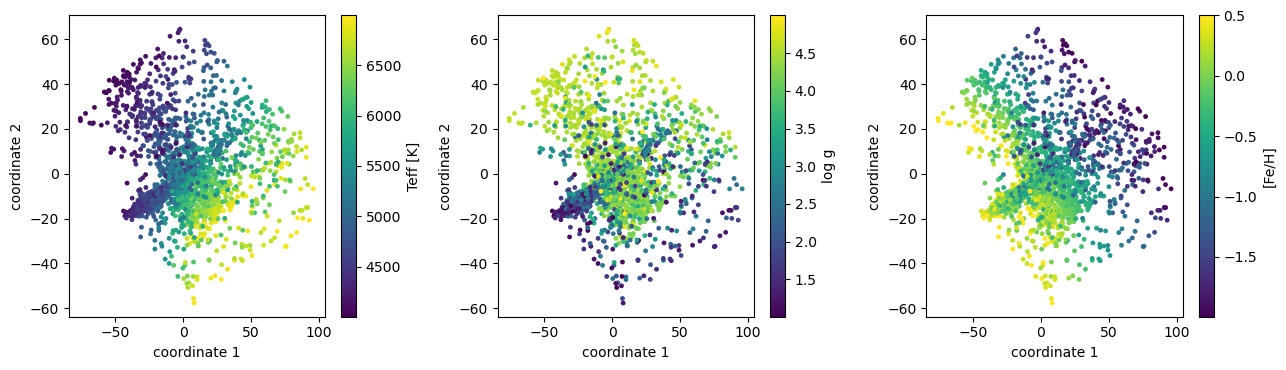

In [4]:
print("eigenvalue ratios:", np.round(F.eigenvalues[:8] / F.eigenvalues[0], 3))
print("seconds per step:", {k: round(v, 1) for k, v in F.timings.items()})
C = F.C
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, j, name in zip(axes, range(3), ["Teff [K]", "log g", "[Fe/H]"]):
    s = ax.scatter(C[:, 0], C[:, 1], c=labels[:, j], s=6, cmap="viridis"); plt.colorbar(s, ax=ax, label=name)
    ax.set_xlabel("coordinate 1"); ax.set_ylabel("coordinate 2")
plt.tight_layout(); plt.show()

No label entered the calculation, yet each label varies smoothly across the cloud: the coordinates are a map of the spectra, and the labels are directions in it.

## 3. Labels for every star from a few labelled ones

Suppose only 50 stars have measured labels. `Fit.propagate` takes the labels of those stars and returns a value for every star, by asking that each star's labels be the same local linear combination of its neighbours' labels as its spectrum is of their spectra. The stars to label are chosen at random here; a survey would draw them so that sparse regions are covered too (the paper's inverse-density draw).

1-sigma errors on the 2050 unlabelled stars from 50 labelled ones:
   Teff   22.357
   log g  0.081
   [Fe/H] 0.049


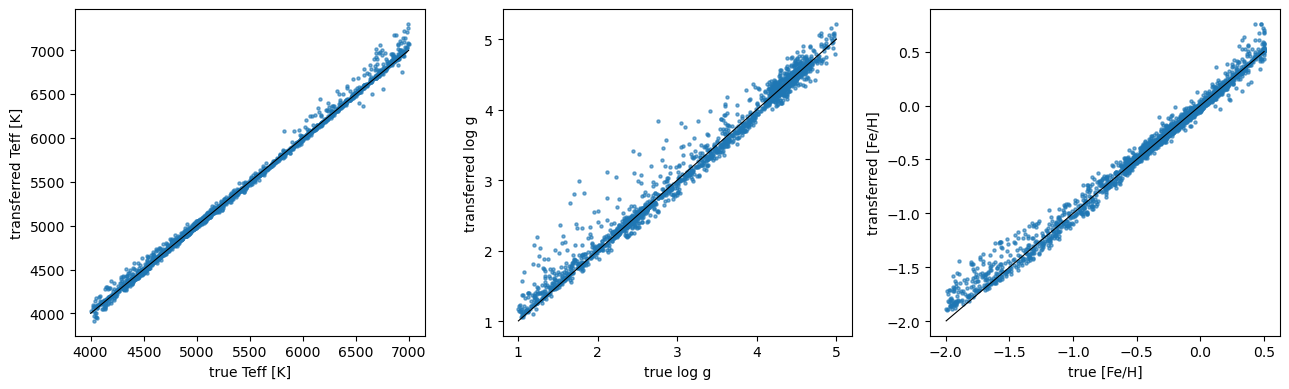

In [5]:
rng = np.random.default_rng(1)
labelled = rng.choice(N, 50, replace=False)
Y = F.propagate(labels, labelled_index=labelled)

held = np.setdiff1d(np.arange(N), labelled)
err = ev.error(Y[held] - labels[held])      # half the central 68 per cent range of the differences, per label
print("1-sigma errors on the", len(held), "unlabelled stars from 50 labelled ones:")
for name, e in zip(["Teff", "log g", "[Fe/H]"], err): print(f"   {name:6s} {e:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, j, name in zip(axes, range(3), ["Teff [K]", "log g", "[Fe/H]"]):
    ax.scatter(labels[held, j], Y[held, j], s=5, alpha=0.6); lo, hi = labels[:, j].min(), labels[:, j].max()
    ax.plot([lo, hi], [lo, hi], "k-", lw=0.8); ax.set_xlabel("true " + name); ax.set_ylabel("transferred " + name)
plt.tight_layout(); plt.show()

## 4. The same with noise

Real spectra carry noise. Add Gaussian noise at a signal-to-noise ratio of 30 per pixel and repeat. The distance is built on cumulative absorption, which averages the noise down within each chunk, so the coordinates and the transfer degrade gracefully.

In [6]:
snr = 30.0
noisy = (flux + rng.normal(0, 1 / snr, flux.shape)).astype(np.float32)
Fn = ar.fit(noisy, good, segments, config, log=None)
Yn = Fn.propagate(labels, labelled_index=labelled)
errn = ev.error(Yn[held] - labels[held])
for name, e0, e1 in zip(["Teff", "log g", "[Fe/H]"], err, errn): print(f"   {name:6s} noiseless {e0:.3f}   S/N 30 {e1:.3f}")

   Teff   noiseless 22.357   S/N 30 49.093
   log g  noiseless 0.081   S/N 30 0.137
   [Fe/H] noiseless 0.049   S/N 30 0.056


## 5. Your own survey

The calls are the same for a real survey; what changes is the input and the configuration.

- **Input.** `flux [N, P]` and `good [N, P]` (False where a pixel is bad), `segments [P]` numbering the detector segments from 0, and `err [N, P]` when the spectra still carry their instrumental response (then `Config(continuum="running")` fits a running continuum first) or when the noise varies across the spectrum in a way the errors describe (`error_weights=True`).
- **Configuration.** `Config()` is the paper's APOGEE setting (three detector segments, three chunkings of increasing fineness, four coordinates); `Config.paper_apogee_survey()` and `Config.paper_desi()` are the two survey-scale settings, with 800 landmarks and nearest-neighbour descent for the neighbour search. Every field is documented in `armillary/pipeline.py`, and a configuration can be saved and loaded as JSON.
- **Scale.** The chain has been run on 200,000 APOGEE and 100,000 DESI spectra on one node; the neighbour search is the cost, and `Config.threads` sets the cores numba uses.
- **Saving.** `F.save(path)` writes the coordinates, eigenvalues, landmarks, neighbour lists and configuration to a compressed `.npz`; `F.propagate` can be called again later on the same `Fit`.

In [7]:
cfg = ar.Config.paper_apogee_survey()
print({k: v for k, v in cfg.to_dict().items() if k in ("chunkings", "k_lattice", "n_landmarks", "d", "k_refine", "search", "mu")})
F.save("examples/output_tutorial_fit.npz")

{'chunkings': ((4, 4, 3), (8, 7, 5), (16, 14, 10)), 'k_lattice': 30, 'search': 'nndescent', 'n_landmarks': 800, 'd': 4, 'k_refine': 100, 'mu': 3.0}
